In [19]:
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

df = yf.download(
    "SPY",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True,
    multi_level_index=False,
)
assert df is not None, "DOWNLOAD FAILED ARGHHH"
df.shape


[*********************100%***********************]  1 of 1 completed


(1258, 5)

data is formatted in a way which gives it two column labels
use multi_level_index = False in order to make it one label

In [20]:
close = df["Close"]

df["ret"] = close.pct_change()
df["vol20"] = df["ret"].rolling(20).std() * np.sqrt(252)


df is a pandas dataframe
in close = df['Close'].squeeze() i took a column and then squeezed it into one column so that it becomes a pandas.Series type 
**REVISION:** .squeeze is not needed if i use multi_level_index = False

.pct_change computes the fractional change from the immediate row and the previous. or the **daily percent change** in price as a decimal.

.rolling(n) takes a window of n and then performs the operation on the n rows that you chain after. For example, .rolling(n).std()

multiplying by np.sqrt(252) normalizes the daily std we calced over 20 days into an annual std. if we want months we can use sqrt12 instead.



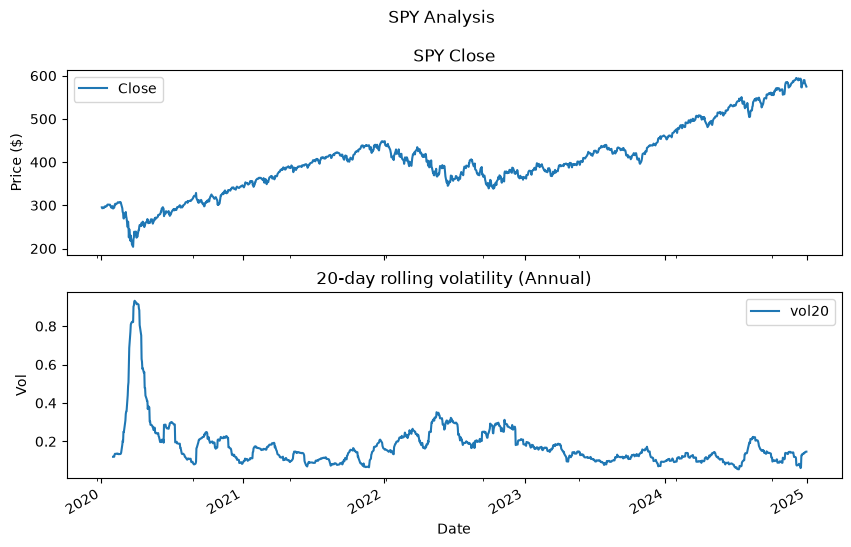

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("SPY Analysis")

close.plot(ax=ax1, title="SPY Close")
ax1.set_ylabel("Price ($)")
ax1.legend()

df["vol20"].plot(ax=ax2, title="20-day rolling volatility (Annual)")
ax2.set_ylabel("Vol")
ax2.legend()
plt.savefig("../images/p1_SPY_analysis.png", dpi=150)
plt.show()


plt.subplots makes a grid with 2 rows and 1 column
returns a tuple of (figure, axes)
figure is the entire frame where plots will be shown.



sharex = True makes both charts share the date axis.



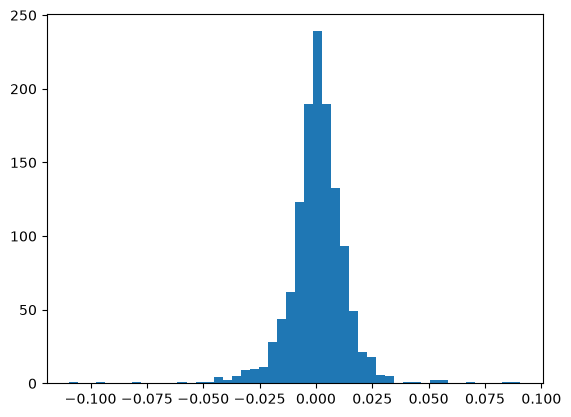

In [22]:
plt.hist(df["ret"].dropna(), bins=50)
plt.show()

prints a histogram of Ret with 50 bins.

In [23]:
print(df["vol20"].max())
print(df["vol20"].idxmax())

0.9318500874044413
2020-03-27 00:00:00


.max() prints the maximum value

.idxmax() prints the date of that max

In [24]:
print(df["ret"].min())
print(df["ret"].idxmin())


-0.1094235984637667
2020-03-16 00:00:00


From this we can see that the returns centralize around 0 on the histogram.
From the tails we see that there are some days with +10% -10% returns too.

Furthermore, the closing price consistently goes up over the years. This was during a period of a historic bull run. The conclusion drawn from the data may change based on the time frame.

Spikes/dips in the vol are seem to be correlated with the close prices. Just eyeballing it seems at higher volatilities the close drops and at lower volatilities the close raises.